<h1 style="color:green;font-size:22px;">Function 7 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 7 is a **6-dimensional** black-box objective over the bounded domain $[0,1]^6$. Its analytical form and the interpretation of its coordinates are unknown. Starting from 30 initial observations, the objective is to **find the input configuration that maximises the best observed value** under a fixed sequential-evaluation budget.

An illustrative analogy is the tuning of six normalised machine-learning hyperparameters. A configuration can be evaluated and returns one performance score, but the relationship between the inputs and the score is unavailable analytically. This analogy is conceptual only: because the challenge does not disclose the meaning of the coordinates, no domain-specific priors are imposed.

The 13 historical queries are organised by strategy phase:

1. **Cartesian RBF-UCB exploration** (Weeks 1–3)
2. **Sobol Matérn-5/2-UCB transition** (Weeks 4–5)
3. **Local Matérn-5/2-EI refinement** (Weeks 6–13)

The historical candidate designs and recorded observations remain the source of truth, while repeated mechanics are kept in compact helpers. The final section evaluates query-budget performance, surrogate robustness, acquisition agreement and local decision stability.


In [12]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing and data handling
import numpy as np
import pandas as pd

# SciPy
from scipy.stats import qmc

# Scikit-learn
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.surrogate import build_kernel, build_gp, fit_gp
from src.acquisition import upper_confidence_bound, expected_improvement
from src.plotting import plot_pairwise_observations_2d, plot_sequential_query_performance
from src.validation import sequential_performance, kernel_choice_validation

from src.search import (
    search_region, 
    filter_candidates,
    original_grid_blocks,
    validate_original_grid_ordering,
    exhaustive_cartesian_search,
    sobol_candidates,
    local_sobol_candidates)

FUNCTION_ID = 7
DIMENSION = 6
INITIAL_OBSERVATIONS = 30
GLOBAL_GRID_RESOLUTION = 15
SOBOL_POWER = 14
GLOBAL_SOBOL_SEED = 42
LOCAL_SOBOL_SEED = 123
LOCAL_RADIUS = np.full(DIMENSION, 0.12)
LOCAL_MIN_DISTANCE = 0.05

np.set_printoptions(precision=6, suppress=True)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

The first step is to inspect the scale of the observed responses and the initial incumbent. In a high-dimensional cube, even several dozen observations remain sparse, so pairwise projections are descriptive rather than a reconstruction of the full objective surface.

In [13]:
data = load_initial_data(FUNCTION_ID)
initial_inputs, initial_outputs = extract(data)
inputs, outputs = initial_inputs.copy(), initial_outputs.copy()

initial_best_idx = int(np.argmax(initial_outputs))
initial_summary = pd.DataFrame([{
    "n_observations": len(initial_outputs),
    "dimension": DIMENSION,
    "initial_best": float(initial_outputs[initial_best_idx])}])

display(initial_summary)
print("Initial incumbent location:", initial_inputs[initial_best_idx])
display(data)


,n_observations,dimension,initial_best
0,30,6,1.364968


Initial incumbent location: [0.057896 0.491672 0.247422 0.218118 0.420428 0.73097 ]


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


**Initial interpretation.** The initial incumbent is approximately **1.364968**. Relative to a 6-dimensional search space, 30 observations do not justify treating any apparent local pattern as globally representative. The first phase therefore keeps the search global and uses a smooth RBF Gaussian process with UCB.


<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Cartesian RBF-UCB exploration (Queries 1–3)</h1>

The historical policy uses:
- an RBF GP with initial length scale $0.2$,
- a Cartesian grid with **15 points per axis**
- the UCB schedule $\kappa=(1.5,\ 1.5,\ 2.50)$.

The recorded observation is always appended to the data path. A recomputed proposal is used only to check reproducibility; a mismatch is reported without replacing the historical query.


In [14]:
def rbf_kernel():
    return RBF(length_scale=0.20, length_scale_bounds=(1e-5, 1e5))+ WhiteKernel(noise_level=1e-6)

phase_1_kappas = {1: 1.50, 2: 1.50, 3: 2.50}
phase_1_rows = []

for week, kappa in phase_1_kappas.items():
    
    current_inputs, current_outputs = extract(data)
    previous_best = float(current_outputs.max())

    gp = GaussianProcessRegressor(kernel=rbf_kernel(), alpha=1e-10, normalize_y=True, random_state=RANDOM_SEED)
    gp.fit(current_inputs, current_outputs)

    search = exhaustive_cartesian_search(
        gp,
        dimension=DIMENSION,
        resolution=GLOBAL_GRID_RESOLUTION,
        kappa=kappa,
        compute_ucb=True)

    proposed = search["ucb_point"]
    recorded, observed_y = historical_record(FUNCTION_ID, week)
    recorded = np.asarray(recorded, dtype=float)
    matches_record = np.allclose(proposed, recorded, atol=5e-6)

    if not matches_record:
        warnings.warn(
            f"Query {week}: recomputed UCB candidate does not match the recorded query.",
            RuntimeWarning)

    phase_1_rows.append({
        "week": week,
        "kappa": kappa,
        "n_candidates_scanned": search["n_candidates"],
        "proposed_candidate": np.round(proposed, 6).tolist(),
        "recorded_query": np.round(recorded, 6).tolist(),
        "matches_record": matches_record,
        "proposal_record_distance": float(np.linalg.norm(proposed - recorded)),
        "observed_y": float(observed_y),
        "previous_incumbent": previous_best,
        "improved_incumbent": float(observed_y) > previous_best})

    data = update_data(data, recorded, observed_y)

phase_1_history = pd.DataFrame(phase_1_rows)
display(phase_1_history.style.set_properties(
    subset=["proposed_candidate", "recorded_query"],
    **{"white-space": "nowrap"}))


Point added!
Point added!
Point added!


,week,kappa,n_candidates_scanned,proposed_candidate,recorded_query,matches_record,proposal_record_distance,observed_y,previous_incumbent,improved_incumbent
0,1,1.500000,11390625,"[0.071429, 0.428571, 0.285714, 0.142857, 0.357143, 0.714286]","[0.071429, 0.428571, 0.285714, 0.142857, 0.357143, 0.714286]",True,0.000001,1.701689,1.364968,True
1,2,1.500000,11390625,"[0.0, 0.357143, 0.357143, 0.0, 0.285714, 0.785714]","[0.0, 0.357143, 0.357143, 0.0, 0.285714, 0.785714]",True,0.000000,1.017737,1.701689,False
2,3,2.500000,11390625,"[0.071429, 0.357143, 0.285714, 0.214286, 0.285714, 0.642857]","[0.071429, 0.357143, 0.285714, 0.214286, 0.285714, 0.642857]",True,0.000001,2.329548,1.701689,True


**Phase result and transition.** The first three evaluations test whether a coarse global lattice can identify a useful region. The tensor-grid cost grows exponentially with dimension, so the next phase keeps the search global but replaces the Cartesian candidate set with a scrambled Sobol design and moves to a Matérn-5/2 surrogate.


<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: Sobol-Matérn 5/2-UCB transition (Weeks 4–5)</h1>

- Week 4 replaces the Cartesian grid with a global scrambled Sobol design of $2^{14}$ points and changes the surrogate from RBF to Matérn-5/2 while retaining UCB with $\kappa=2.50$.
- Week 5 then centres a local Sobol design around the current incumbent and still selects **UCB**, with EI computed on the same candidates as a transition diagnostic.


In [15]:
#Kernels definition

def matern_52_kernel():
    return Matern(length_scale=np.full(DIMENSION, 0.20), nu=2.5) + WhiteKernel(noise_level=1e-5)

def local_matern_52_kernel(initial_scale=0.20):
    """Historical local Matérn-5/2 specification."""
    return (ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=np.full(DIMENSION, initial_scale),
                     length_scale_bounds=(1e-2, 3.0),
                     nu=2.5)
            + WhiteKernel(noise_level=1e-6,
                          noise_level_bounds=(1e-8, 1e-2)))

In [16]:
phase_2_rows = []

# Query 4: global Sobol / Matérn UCB transition
week = 4
current_inputs, current_outputs = extract(data)
previous_best = float(current_outputs.max())

transition_candidates = qmc.Sobol(
    d=DIMENSION,
    scramble=True,
    seed=GLOBAL_SOBOL_SEED).random_base2(SOBOL_POWER)

transition_gp = GaussianProcessRegressor(
    kernel=matern_52_kernel(),
    alpha=1e-10,
    normalize_y=True,
    random_state=RANDOM_SEED).fit(current_inputs, current_outputs)

mean, std = transition_gp.predict(transition_candidates, return_std=True)
kappa = 2.50
ucb = upper_confidence_bound(mean, std, kappa=kappa)
selected_point = transition_candidates[int(np.argmax(ucb))]
recorded, observed_y = historical_record(FUNCTION_ID, week)
recorded = np.asarray(recorded, dtype=float)
selected_matches_record = np.allclose(selected_point, recorded, atol=5e-6)

if not selected_matches_record:
    warnings.warn("Query 4: recomputed Sobol/Matérn UCB candidate differs from the recorded query.", RuntimeWarning)

phase_2_rows.append({
    "week": week,
    "stage": "Global Sobol transition",
    "candidate_design": f"Sobol 2^{SOBOL_POWER}",
    "selected_acquisition": "UCB",
    "xi": np.nan,
    "kappa": kappa,
    "n_candidates_after_filter": len(transition_candidates),
    "EI_proposal": None,
    "UCB_proposal": np.round(selected_point, 6).tolist(),
    "selected_proposal": np.round(selected_point, 6).tolist(),
    "recorded_query": np.round(recorded, 6).tolist(),
    "selected_matches_record": selected_matches_record,
    "proposal_record_distance": float(np.linalg.norm(selected_point - recorded)),
    "EI_UCB_distance": np.nan,
    "observed_y": float(observed_y),
    "previous_incumbent": previous_best,
    "improved_incumbent": float(observed_y) > previous_best})

data = update_data(data, recorded, observed_y)

# Query 5: local Sobol / Matérn UCB localisation
week = 5
current_inputs, current_outputs = extract(data)
incumbent_idx = int(np.argmax(current_outputs))
incumbent_x = current_inputs[incumbent_idx].copy()
incumbent_y = float(current_outputs[incumbent_idx])
xi = 0.005
kappa = 2.5 / np.sqrt(week)

candidates, lower, upper = local_sobol_candidates(
    centre=incumbent_x,
    radius=LOCAL_RADIUS,
    observed_inputs=current_inputs,
    power=SOBOL_POWER,
    seed=LOCAL_SOBOL_SEED,
    min_distance=LOCAL_MIN_DISTANCE)

gp = GaussianProcessRegressor(
    kernel=local_matern_52_kernel(0.20),
    normalize_y=True,
    n_restarts_optimizer=12,
    random_state=RANDOM_SEED).fit(current_inputs, current_outputs)

mean, std = gp.predict(candidates, return_std=True)
ei = expected_improvement(mean, std, best=incumbent_y, xi=xi)
ucb = upper_confidence_bound(mean, std, kappa=kappa)
ei_point = candidates[int(np.argmax(ei))]
ucb_point = candidates[int(np.argmax(ucb))]
selected_point = ucb_point

recorded, observed_y = historical_record(FUNCTION_ID, week)
recorded = np.asarray(recorded, dtype=float)
selected_matches_record = np.allclose(selected_point, recorded, atol=5e-6)

if not selected_matches_record:
    warnings.warn("Query 5: local UCB proposal differs from the recorded query.",RuntimeWarning)

phase_2_rows.append({
    "week": week,
    "stage": "Local Sobol localisation",
    "candidate_design": f"Local Sobol 2^{SOBOL_POWER}",
    "selected_acquisition": "UCB",
    "xi": xi,
    "kappa": kappa,
    "n_candidates_after_filter": len(candidates),
    "EI_proposal": np.round(ei_point, 6).tolist(),
    "UCB_proposal": np.round(ucb_point, 6).tolist(),
    "selected_proposal": np.round(selected_point, 6).tolist(),
    "recorded_query": np.round(recorded, 6).tolist(),
    "selected_matches_record": selected_matches_record,
    "proposal_record_distance": float(np.linalg.norm(selected_point - recorded)),
    "EI_UCB_distance": float(np.linalg.norm(ei_point - ucb_point)),
    "observed_y": float(observed_y),
    "previous_incumbent": incumbent_y,
    "improved_incumbent": float(observed_y) > incumbent_y})

data = update_data(data, recorded, observed_y)
phase_2_history = pd.DataFrame(phase_2_rows)
display(phase_2_history.style.set_properties(
    subset=["EI_proposal", "UCB_proposal", "selected_proposal", "recorded_query"],
    **{"white-space": "nowrap"}))


Point added!
Point added!


,week,stage,candidate_design,selected_acquisition,xi,kappa,n_candidates_after_filter,EI_proposal,UCB_proposal,selected_proposal,recorded_query,selected_matches_record,proposal_record_distance,EI_UCB_distance,observed_y,previous_incumbent,improved_incumbent
0,4,Global Sobol transition,Sobol 2^14,UCB,nan,2.500000,16384,None,"[0.044056, 0.134912, 0.123144, 0.13304, 0.267774, 0.554953]","[0.044056, 0.134912, 0.123144, 0.13304, 0.267774, 0.554953]","[0.044056, 0.134912, 0.123144, 0.13304, 0.267774, 0.554953]",True,0.000001,nan,1.734759,2.329548,False
1,5,Local Sobol localisation,Local Sobol 2^14,UCB,0.005000,1.118034,16372,"[0.012283, 0.259872, 0.373294, 0.215267, 0.308625, 0.633826]","[0.012283, 0.259872, 0.373294, 0.215267, 0.308625, 0.633826]","[0.012283, 0.259872, 0.373294, 0.215267, 0.308625, 0.633826]","[0.012283, 0.259872, 0.373294, 0.215267, 0.308625, 0.633826]",True,0.000001,0.000000,2.580636,2.329548,True


**Phase result and transition.** Query 4 removes the tensor-grid bottleneck while preserving global coverage. Query 5 then localises the search around the incumbent but still uses UCB as the selected acquisition. From Query 6 onward, the candidate design remains local and the selected acquisition switches cleanly to EI.


<h1 style="color:#0000CD;font-size:19px;">4. Phase 3: Local Matérn-5/2 EI refinement (Queries 6–13)</h1>

The refinement phase keeps the local design established at Query 5:

- **surrogate:** Constant $\times$ Matérn-5/2 with optimised length scales;
- **search region:** radius $0.12$ per coordinate around the current incumbent, clipped to $[0,1]^6$;
- **candidate set:** scrambled Sobol, $2^{14}$ points, seed 123;
- **minimum distance:** $0.05$ from existing observations;
- **selected acquisition:** EI with $\xi=0.005$ for Queries 6–12 and $\xi=0$ for Query 13;
- **UCB diagnostic:** $\kappa=2.5/\sqrt{t}$, evaluated on the same local candidates.


In [17]:
phase_3_rows = []

for week in range(6, 14):
    current_inputs, current_outputs = extract(data)
    incumbent_idx = int(np.argmax(current_outputs))
    incumbent_x = current_inputs[incumbent_idx].copy()
    incumbent_y = float(current_outputs[incumbent_idx])
    xi = 0.0 if week == 13 else 0.005
    kappa = 2.5 / np.sqrt(week)

    candidates, lower, upper = local_sobol_candidates(
        centre=incumbent_x,
        radius=LOCAL_RADIUS,
        observed_inputs=current_inputs,
        power=SOBOL_POWER,
        seed=LOCAL_SOBOL_SEED,
        min_distance=LOCAL_MIN_DISTANCE)

    gp = GaussianProcessRegressor(
        kernel=local_matern_52_kernel(0.20),
        normalize_y=True,
        n_restarts_optimizer=12,
        random_state=RANDOM_SEED,
    ).fit(current_inputs, current_outputs)

    mean, std = gp.predict(candidates, return_std=True)
    ei = expected_improvement(mean, std, best=incumbent_y, xi=xi)
    ucb = upper_confidence_bound(mean, std, kappa=kappa)

    ei_point = candidates[int(np.argmax(ei))]
    ucb_point = candidates[int(np.argmax(ucb))]
    selected_point = ei_point

    recorded, observed_y = historical_record(FUNCTION_ID, week)
    recorded = np.asarray(recorded, dtype=float)
    selected_matches_record = np.allclose(selected_point, recorded, atol=5e-6)

    if not selected_matches_record:
        warnings.warn(
            f"Query {week}: EI proposal differs from the recorded query.",
            RuntimeWarning,
        )

    phase_3_rows.append({
        "week": week,
        "selected_acquisition": "EI",
        "xi": xi,
        "kappa": kappa,
        "n_candidates_after_filter": len(candidates),
        "EI_proposal": np.round(ei_point, 6).tolist(),
        "UCB_proposal": np.round(ucb_point, 6).tolist(),
        "selected_proposal": np.round(selected_point, 6).tolist(),
        "recorded_query": np.round(recorded, 6).tolist(),
        "selected_matches_record": selected_matches_record,
        "proposal_record_distance": float(np.linalg.norm(selected_point - recorded)),
        "EI_UCB_distance": float(np.linalg.norm(ei_point - ucb_point)),
        "observed_y": float(observed_y),
        "previous_incumbent": incumbent_y,
        "improved_incumbent": float(observed_y) > incumbent_y,
    })

    # The recorded query remains the single historical source of truth.
    data = update_data(data, recorded, observed_y)

phase_3_history = pd.DataFrame(phase_3_rows)
display(phase_3_history.style.set_properties(
    subset=["EI_proposal", "UCB_proposal", "selected_proposal", "recorded_query"],
    **{"white-space": "nowrap"},
))


Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!


,week,selected_acquisition,xi,kappa,n_candidates_after_filter,EI_proposal,UCB_proposal,selected_proposal,recorded_query,selected_matches_record,proposal_record_distance,EI_UCB_distance,observed_y,previous_incumbent,improved_incumbent
0,6,EI,0.005000,1.020621,16368,"[0.001903, 0.18372, 0.41863, 0.234987, 0.305263, 0.62363]","[0.003944, 0.247949, 0.471606, 0.264695, 0.307889, 0.584127]","[0.001903, 0.18372, 0.41863, 0.234987, 0.305263, 0.62363]","[0.001903, 0.18372, 0.41863, 0.234987, 0.305263, 0.62363]",True,0.000001,0.096880,2.736811,2.580636,True
1,7,EI,0.005000,0.944911,16367,"[0.003635, 0.171797, 0.516942, 0.284415, 0.304527, 0.573931]","[0.000799, 0.068109, 0.378711, 0.293561, 0.298881, 0.742406]","[0.003635, 0.171797, 0.516942, 0.284415, 0.304527, 0.573931]","[0.003635, 0.171797, 0.516942, 0.284415, 0.304527, 0.573931]",True,0.000001,0.241591,2.684600,2.736811,False
2,8,EI,0.005000,0.883883,16361,"[0.001753, 0.107568, 0.463966, 0.254707, 0.301901, 0.613434]","[0.001753, 0.107568, 0.463966, 0.254707, 0.301901, 0.613434]","[0.001753, 0.107568, 0.463966, 0.254707, 0.301901, 0.613434]","[0.001753, 0.107568, 0.463966, 0.254707, 0.301901, 0.613434]",True,0.000001,0.000000,2.772707,2.736811,True
3,9,EI,0.005000,0.833333,16360,"[0.003399, 0.027122, 0.558293, 0.252431, 0.306684, 0.541311]","[0.003399, 0.027122, 0.558293, 0.252431, 0.306684, 0.541311]","[0.003399, 0.027122, 0.558293, 0.252431, 0.306684, 0.541311]","[0.003399, 0.027122, 0.558293, 0.252431, 0.306684, 0.541311]",True,0.000000,0.000000,2.384170,2.772707,False
4,10,EI,0.005000,0.790569,16353,"[0.003521, 0.135486, 0.488938, 0.273657, 0.303514, 0.685359]","[0.003521, 0.135486, 0.488938, 0.273657, 0.303514, 0.685359]","[0.003521, 0.135486, 0.488938, 0.273657, 0.303514, 0.685359]","[0.003521, 0.135486, 0.488938, 0.273657, 0.303514, 0.685359]",True,0.000001,0.000000,2.832769,2.772707,True
5,11,EI,0.005000,0.753778,16354,"[0.00101, 0.070012, 0.598392, 0.291353, 0.331428, 0.658622]","[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]","[0.00101, 0.070012, 0.598392, 0.291353, 0.331428, 0.658622]","[0.00101, 0.070012, 0.598392, 0.291353, 0.331428, 0.658622]",True,0.000001,0.215595,2.625874,2.832769,False
6,12,EI,0.005000,0.721688,16347,"[0.006862, 0.138197, 0.470817, 0.295639, 0.267625, 0.648131]","[0.024312, 0.15468, 0.563418, 0.287759, 0.281534, 0.669517]","[0.006862, 0.138197, 0.470817, 0.295639, 0.267625, 0.648131]","[0.006862, 0.138197, 0.470817, 0.295639, 0.267625, 0.648131]",True,0.000001,0.099319,2.773992,2.832769,False
7,13,EI,0.000000,0.693375,16339,"[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]","[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]","[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]","[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]",True,0.000001,0.000000,2.854626,2.832769,True


**Phase result.** The local stage repeatedly samples the incumbent neighbourhood rather than the full domain. The best observed Function 7 value is reached at Query **13** with approximately **2.854626**. The later observations should be read as local evidence under the remaining budget, not as proof that the hidden global maximum has been found.


In [18]:
# Compact reconstruction of the realised historical query path
inputs, outputs = extract(data)
query_inputs = inputs[INITIAL_OBSERVATIONS:]
query_outputs = outputs[INITIAL_OBSERVATIONS:]

path_rows = []
running_best = float(initial_outputs.max())

for week, (point, value) in enumerate(zip(query_inputs, query_outputs), start=1):
    previous_best = running_best
    running_best = max(running_best, float(value))

    if week <= 3:
        phase = "Global RBF-UCB Cartesian"
        acquisition = "UCB"
    elif week <= 5:
        phase = "Sobol / Matern transition and localisation"
        acquisition = "UCB"
    else:
        phase = "Local Matern-EI refinement"
        acquisition = "EI"

    path_rows.append({
        "week": week,
        "phase": phase,
        "selected_acquisition": acquisition,
        **{f"x{i+1}": point[i] for i in range(DIMENSION)},
        "observed_y": float(value),
        "previous_incumbent": previous_best,
        "best_so_far": running_best,
        "improved_incumbent": float(value) > previous_best,
    })

query_history = pd.DataFrame(path_rows)
display(query_history.style.set_properties(
    subset=["phase"],
    **{"white-space": "nowrap"}))


,week,phase,selected_acquisition,x1,x2,x3,x4,x5,x6,observed_y,previous_incumbent,best_so_far,improved_incumbent
0,1,Global RBF-UCB Cartesian,UCB,0.071429,0.428571,0.285714,0.142857,0.357143,0.714286,1.701689,1.364968,1.701689,True
1,2,Global RBF-UCB Cartesian,UCB,0.000000,0.357143,0.357143,0.000000,0.285714,0.785714,1.017737,1.701689,1.701689,False
2,3,Global RBF-UCB Cartesian,UCB,0.071429,0.357143,0.285714,0.214286,0.285714,0.642857,2.329548,1.701689,2.329548,True
3,4,Sobol / Matern transition and localisation,UCB,0.044056,0.134912,0.123144,0.133040,0.267774,0.554953,1.734759,2.329548,2.329548,False
4,5,Sobol / Matern transition and localisation,UCB,0.012283,0.259872,0.373294,0.215267,0.308625,0.633826,2.580636,2.329548,2.580636,True
5,6,Local Matern-EI refinement,EI,0.001903,0.183720,0.418630,0.234987,0.305263,0.623630,2.736811,2.580636,2.736811,True
6,7,Local Matern-EI refinement,EI,0.003635,0.171797,0.516942,0.284415,0.304527,0.573931,2.684600,2.736811,2.736811,False
7,8,Local Matern-EI refinement,EI,0.001753,0.107568,0.463966,0.254707,0.301901,0.613434,2.772707,2.736811,2.772707,True
8,9,Local Matern-EI refinement,EI,0.003399,0.027122,0.558293,0.252431,0.306684,0.541311,2.384170,2.772707,2.772707,False
9,10,Local Matern-EI refinement,EI,0.003521,0.135486,0.488938,0.273657,0.303514,0.685359,2.832769,2.772707,2.832769,True


**Final observed solution.** The best observed point is

$$[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]$$

with objective value approximately **2.854626**, obtained at **Query 13**.

This is the **best observed configuration under the available query budget**, not proof of the global maximum.


<h1 style="color:#0000CD;font-size:19px;">5. Quantitative Evaluation</h1>

The retrospective evaluation separates four questions:

1. **Performance:** how much did the 13-query budget improve the initial incumbent?
2. **Surrogate robustness:** do the historical RBF and local Matérn-5/2 model families give materially different out-of-sample prediction or ranking performance?
3. **Acquisition / record diagnostic:** from the Query 5 localisation step onward, when EI and UCB are evaluated on the same local candidates, how often do they agree and how closely does the selected proposal reproduce the recorded query?
4. **Local decision stability:** does the strongest late-stage decision depend materially on one Matérn starting scale or one exact local radius?

These checks use only the observations available in the project and reconstructed historical candidate designs. They do not reveal the hidden function at unevaluated points.


**5.1 - Sequential and query-budget performance**

Each realised query is compared with the incumbent available immediately before that query.


,metric,value
0,Initial incumbent,1.364968
1,Final best observed,2.854626
2,Absolute improvement,1.489658
3,Relative improvement,1.091350
4,Queries improving incumbent,7.000000


,query,query_output,best_so_far,improvement
0,1,1.701689,1.701689,0.336720
1,2,1.017737,1.701689,0.000000
2,3,2.329548,2.329548,0.627859
3,4,1.734759,2.329548,0.000000
4,5,2.580636,2.580636,0.251088
5,6,2.736811,2.736811,0.156175
6,7,2.684600,2.736811,0.000000
7,8,2.772707,2.772707,0.035896
8,9,2.384170,2.772707,0.000000
9,10,2.832769,2.832769,0.060062


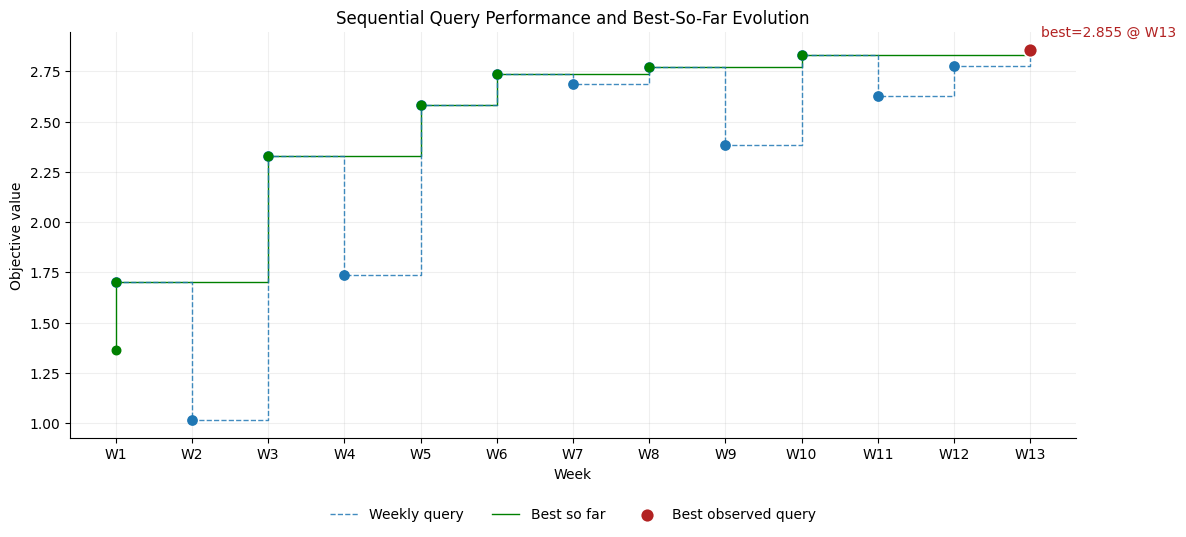

In [19]:
performance, performance_summary = sequential_performance(
    initial_outputs=initial_outputs,
    query_outputs=query_outputs)

display(performance_summary)
display(performance)
plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar")


**Performance result.** The incumbent rises from approximately **1.364968** to **2.854626**, an absolute gain of about **1.489658** and a relative increase of roughly **109%**. **7 of the 13** sequential queries improve the incumbent directly: Queries **1, 3, 5, 6, 8, 10 and 13**.


**5.2 - Surrogate robustness**

The historical experiment begins with an RBF GP and later uses Matérn-5/2 locally. The comparison below evaluates both model families retrospectively on the complete observed dataset.

- **LOOCV RMSE:** lower is better.
- **Spearman rank correlation:** higher means better preservation of the ordering of relatively strong and weak observations.

This is a model-form diagnostic, not a claim that the best full-sample validation model should have been known at the start of the experiment.


In [20]:
predictive_kernels = {
    "Global RBF": rbf_kernel(),
    "Global Matern_52": matern_52_kernel(),
    "Local Matern_52": local_matern_52_kernel()}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED)

display(surrogate_robustness)


,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,Global RBF,0.320815,0.844458
1,Global Matern_52,0.330370,0.875717
2,Local Matern_52,0.266632,0.841438


**Interpretation:** All three specifications achieve relatively strong Spearman rank correlations, with Spearman coefficients between 0.841 and 0.876. Against this broadly comparable ranking performance, the Local Matérn provides the clearest separation in predictive accuracy, reducing RMSE to 0.267, around 17–19% below the global specifications. Overall, the results support the later shift toward a local Matérn surrogate.

**5.3 - Acquisition agreement and historical fidelity**

Query 5 and the subsequent EI-refinement phase store EI and UCB proposals computed on the same local candidate set. The table below shows the EI-UCB separation and whether the historically selected proposal reproduces the recorded query.


In [21]:
diagnostic_columns = [
    "week",
    "selected_acquisition",
    "selected_matches_record",
    "EI_UCB_distance",
    "observed_y",
    "improved_incumbent"]

acquisition_diagnostic = pd.concat([
    phase_2_history.loc[
        phase_2_history["week"] == 5,
        diagnostic_columns,
    ],
    phase_3_history[diagnostic_columns],
], ignore_index=True)

# EI/UCB agreement diagnostic
agreement_mask = acquisition_diagnostic["EI_UCB_distance"] <= 5e-6
disagreement_distances = acquisition_diagnostic.loc[
    ~agreement_mask,
    "EI_UCB_distance"]

acquisition_summary = pd.DataFrame([{
    "local_queries": len(acquisition_diagnostic),
    "selected_proposal_matches_record": int(
        acquisition_diagnostic["selected_matches_record"].sum()),
    "EI_UCB_agreements": int(agreement_mask.sum()),
    "EI_UCB_disagreements": int((~agreement_mask).sum()),
    "agreement_rate": float(agreement_mask.mean()),
    "mean_distance_when_different": float(disagreement_distances.mean()),
    "max_distance_when_different": float(disagreement_distances.max())}])

display(acquisition_summary)
display(acquisition_diagnostic)

,local_queries,selected_proposal_matches_record,EI_UCB_agreements,EI_UCB_disagreements,agreement_rate,mean_distance_when_different,max_distance_when_different
0,9,9,5,4,0.555556,0.163346,0.241591


,week,selected_acquisition,selected_matches_record,EI_UCB_distance,observed_y,improved_incumbent
0,5,UCB,True,0.000000,2.580636,True
1,6,EI,True,0.096880,2.736811,True
2,7,EI,True,0.241591,2.684600,False
3,8,EI,True,0.000000,2.772707,True
4,9,EI,True,0.000000,2.384170,False
5,10,EI,True,0.000000,2.832769,True
6,11,EI,True,0.215595,2.625874,False
7,12,EI,True,0.099319,2.773992,False
8,13,EI,True,0.000000,2.854626,True


**Interpretation:** The selected acquisition reproduces the recorded query in all 9 local evaluations. EI and UCB select the same candidate in 5 of 9 cases; when they disagree, their Euclidean separation ranges from about 0.097 to 0.242. Historical reproducibility is therefore strong, while acquisition agreement is only partial.


**5.4 - Local Matérn decision stability**

Query **13** is used as the stability checkpoint because it is the local decision that produced the final incumbent for Function 7. The state immediately before that query is reconstructed from the stored historical observations. Two choices are then varied separately:

1. the Matérn starting length scale; and
2. the local-radius multiplier.

The Sobol seed, Sobol power, minimum-distance rule and EI setting are otherwise kept fixed. The number of candidates retained after filtering may vary slightly with the search radius.

In [22]:
# Reconstruct the state immediately before Query 13.
stability_week = 13
stability_xi = 0.0

stability_data = load_initial_data(FUNCTION_ID)

for week in range(1, stability_week):
    point, value = historical_record(FUNCTION_ID, week)
    stability_data = update_data(stability_data, point, value)

stability_inputs, stability_outputs = extract(stability_data)

stability_idx = int(np.argmax(stability_outputs))
stability_incumbent_x = stability_inputs[stability_idx].copy()
stability_incumbent_y = float(stability_outputs[stability_idx])

historical_stability_query, _ = historical_record(
    FUNCTION_ID,
    stability_week)

historical_stability_query = np.asarray(
    historical_stability_query,
    dtype=float)


# ------------------------------------------------------------
# Matérn initialisation sensitivity
# Keep the candidate set fixed and vary only the starting scale.
# ------------------------------------------------------------
stability_candidates, _, _ = local_sobol_candidates(
    centre=stability_incumbent_x,
    radius=LOCAL_RADIUS,
    observed_inputs=stability_inputs,
    power=SOBOL_POWER,
    seed=LOCAL_SOBOL_SEED,
    min_distance=LOCAL_MIN_DISTANCE)

scale_rows = []

for initial_scale in [0.10, 0.20, 0.40]:
    gp = GaussianProcessRegressor(
        kernel=local_matern_52_kernel(initial_scale),
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=RANDOM_SEED,
    ).fit(stability_inputs, stability_outputs)

    mean, std = gp.predict(stability_candidates, return_std=True)

    scores = expected_improvement(
        mean,
        std,
        best=stability_incumbent_y,
        xi=stability_xi)

    candidate = stability_candidates[int(np.argmax(scores))]

    scale_rows.append({
        "initial_scale": initial_scale,
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_incumbent": float(np.linalg.norm(candidate - stability_incumbent_x)),
        "distance_to_historical_query": float(np.linalg.norm(candidate - historical_stability_query)),
        "EI_max": float(scores.max()),
        "fitted_kernel": str(gp.kernel_)})

matern_initialisation_sensitivity = pd.DataFrame(scale_rows)

display(matern_initialisation_sensitivity.style.set_properties(
        subset=["candidate", "fitted_kernel"],
        **{"white-space": "nowrap"}))


# ------------------------------------------------------------
# Local-radius sensitivity
# Keep the fitted GP fixed and vary only the search radius.
# ------------------------------------------------------------
historical_gp = GaussianProcessRegressor(
    kernel=local_matern_52_kernel(0.20),
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=RANDOM_SEED,
).fit(stability_inputs, stability_outputs)

radius_rows = []

for multiplier in [0.75, 1.00, 1.25]:
    radius = LOCAL_RADIUS * multiplier

    candidates, _, _ = local_sobol_candidates(
        centre=stability_incumbent_x,
        radius=radius,
        observed_inputs=stability_inputs,
        power=SOBOL_POWER,
        seed=LOCAL_SOBOL_SEED,
        min_distance=LOCAL_MIN_DISTANCE)

    mean, std = historical_gp.predict(candidates, return_std=True)

    scores = expected_improvement(
        mean,
        std,
        best=stability_incumbent_y,
        xi=stability_xi)

    candidate = candidates[int(np.argmax(scores))]

    radius_rows.append({
        "radius_multiplier": multiplier,
        "radius_per_dimension": float(radius[0]),
        "n_candidates_after_filter": len(candidates),
        "candidate": np.round(candidate, 6).tolist(),
        "distance_to_incumbent": float(np.linalg.norm(candidate - stability_incumbent_x)),
        "distance_to_historical_query": float(np.linalg.norm(candidate - historical_stability_query)),
        "EI_max": float(scores.max())})

local_radius_sensitivity = pd.DataFrame(radius_rows)

display(local_radius_sensitivity.style.set_properties(
        subset=["candidate"],
        **{"white-space": "nowrap"}))

Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!
Point added!


,initial_scale,candidate,distance_to_incumbent,distance_to_historical_query,EI_max,fitted_kernel
0,0.100000,"[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]",0.099696,0.000001,0.011799,"0.604**2 * Matern(length_scale=[0.877, 0.732, 3, 0.292, 0.203, 0.428], nu=2.5) + WhiteKernel(noise_level=1e-08)"
1,0.200000,"[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]",0.099696,0.000001,0.011799,"0.604**2 * Matern(length_scale=[0.877, 0.732, 3, 0.292, 0.203, 0.428], nu=2.5) + WhiteKernel(noise_level=1e-08)"
2,0.400000,"[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]",0.099696,0.000001,0.011798,"0.604**2 * Matern(length_scale=[0.877, 0.732, 3, 0.292, 0.203, 0.428], nu=2.5) + WhiteKernel(noise_level=1e-08)"


,radius_multiplier,radius_per_dimension,n_candidates_after_filter,candidate,distance_to_incumbent,distance_to_historical_query,EI_max
0,0.750000,0.090000,16213,"[0.013316, 0.143738, 0.423231, 0.280868, 0.298359, 0.653494]",0.074669,0.025042,0.014882
1,1.000000,0.120000,16339,"[0.017588, 0.146489, 0.401328, 0.283271, 0.296641, 0.642872]",0.099696,0.000001,0.011799
2,1.250000,0.150000,16363,"[0.021859, 0.155831, 0.379426, 0.285675, 0.294923, 0.63225]",0.125626,0.026585,0.007436


**Decision-stability interpretation.** Nearby initial scales and radius choices may move the exact Sobol maximiser, which is expected in a finite high-dimensional candidate set. The important question is whether the recommendations remain concentrated around the same incumbent neighbourhood. If they do, the late-stage decision is not explained by one arbitrary starting scale or one exact trust-region width.


<h1 style="color:#0000CD;font-size:19px;">6. Conclusion and limitations</h1>

Function 7 improves the initial incumbent from approximately **1.364968** to **2.854626** over 13 sequential evaluations. The search has a clear progression: coarse Cartesian UCB finds a promising region, the Sobol/Matérn transition and localisation remove the tensor-grid bottleneck, and the local Matérn-EI phase produces the majority of the later incumbent improvements, including the final one at Query 13.

The historical query path is organised explicitly through `phase_1_history`, `phase_2_history` and `phase_3_history`. Recomputed proposals are diagnostics; the observation loaded through `historical_record()` remains the single source of truth for the realised experiment.

The quantitative evaluation separates realised performance from model robustness and decision sensitivity. In a 6-dimensional domain, exact candidate coordinates are naturally more sensitive to finite candidate designs than in low dimensions, so the strongest defensible conclusion is **regional stability of the late-stage local decision**, not proof of global optimality.
